<a href="https://colab.research.google.com/github/abeerhashmi1212-cloud/abeerhashmi1212.github.io/blob/main/Copy_of_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2



## Question 1

A nuclear fuel pellet is a cylinder, 1.5 cm in lenth and 1 cm in diameter. Assume the surface temperature is 300 C everywhere. Given temperature probe data below, determine the radial temperature profile in the middle of a nuclear fuel pellet (i.e.: T(r, z = 0.75)) using radial basis functions.


In [1]:
import numpy as np

# 20 data points presented in columns: | x | y | z | T |, measurements in cm

data = np.array([
    [5.1690e-02, 2.3766e-01, 6.7059e-01, 5.2645e+02],
    [1.1353e-01, 9.4708e-02, 5.3856e-01, 5.5201e+02],
    [1.6676e-01, 1.4358e-01, 4.6936e-01, 5.0802e+02],
    [1.3610e-01, 3.7207e-02, 2.1694e-01, 4.3663e+02],
    [8.9225e-02, 3.7293e-01, 1.1270e+00, 3.9234e+02],
    [1.9001e-01, 3.7240e-01, 8.4774e-01, 3.8872e+02],
    [5.4849e-02, 3.5425e-01, 5.7478e-01, 4.3784e+02],
    [1.7001e-01, 2.0241e-01, 1.2960e+00, 4.0159e+02],
    [2.0606e-01, 3.1594e-01, 6.4077e-01, 4.2652e+02],
    [2.5382e-01, 2.5859e-01, 4.8610e-01, 4.2481e+02],
    [5.6038e-02, 8.2231e-02, 4.2029e-01, 5.3244e+02],
    [3.1242e-01, 8.0489e-02, 1.1530e+00, 4.2453e+02],
    [6.0186e-02, 4.4891e-01, 3.9941e-01, 3.4207e+02],
    [1.5070e-01, 3.4794e-01, 1.5595e-01, 3.4750e+02],
    [1.8215e-01, 3.4388e-01, 1.0478e+00, 3.9963e+02],
    [1.1633e-01, 4.1011e-01, 5.5001e-01, 3.7611e+02],
    [1.2377e-01, 3.3703e-01, 3.7672e-02, 3.1423e+02],
    [4.6378e-02, 3.3653e-01, 1.4434e+00, 3.2345e+02],
    [2.9063e-02, 3.2584e-02, 2.3977e-01, 4.5993e+02],
    [2.1162e-02, 3.8590e-01, 2.5905e-01, 3.6901e+02]
])

Consider what you know about this system. What extra information do you have in terms of

### a) type(s) of symmetry?

{answer}

Rotational Symmetry, Axial Symmetry

### b) Boundary conditions?

{answer}

Surface Temperature, Radial Boundary, Axial Boundaries, Centerline

## c) Plot the best guess of the radial temperature profile

Note: RBFs will fail with a linear solver error if two data points exactly overlap.

{Method, implementation, answer, answer}

Condition number: 3.268994648278723e+23


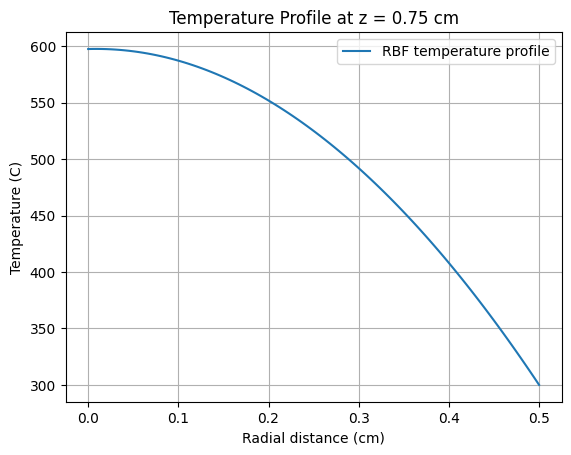

In [4]:
import matplotlib.pyplot as plt

# Convert x and y coordinates to radial distances
r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)

# Combine the radial distances and z coordinates
points = np.column_stack((r, data[:, 2]))

# Extract the measured temperatures
T = data[:, 3]

# Generate points along the curved outer surface
z_side = np.linspace(0, 1.5, 31)
r_side = np.full(len(z_side), 0.5)

# Generate points across the two flat ends
r_ends = np.linspace(0, 0.5, 21)
z_bottom = np.zeros(len(r_ends))
z_top = np.full(len(r_ends), 1.5)

# Combine the surface points
boundary_points = np.vstack((
    np.column_stack((r_side, z_side)),
    np.column_stack((r_ends, z_bottom)),
    np.column_stack((r_ends, z_top))
))

# Assign a temperature of 300 C to all surface points
boundary_T = np.full(len(boundary_points), 300.0)

# Combine the measured points and surface points
all_points = np.vstack((points, boundary_points))
all_T = np.concatenate((T, boundary_T))

# Define the Gaussian radial basis function
def gaussian_rbf(r, epsilon):
    return np.exp(-(epsilon * r)**2)

# Calculate the distance matrix between all points
dist_matrix = np.sqrt(
    (all_points[:, 0, np.newaxis] - all_points[:, 0])**2
    + (all_points[:, 1, np.newaxis] - all_points[:, 1])**2
)

# Calculate the average distance between points
average_distance = np.mean(dist_matrix)

# Calculate epsilon using the textbook's rule
epsilon = 1 / average_distance

# Create the RBF matrix using the Gaussian function
phi_matrix = gaussian_rbf(dist_matrix, epsilon)

# Check the condition number of the matrix
print("Condition number:", np.linalg.cond(phi_matrix))

# Solve the linear system to find the RBF weights
weights = np.linalg.solve(phi_matrix, all_T)

# Define the interpolation function
def interpolation_function(r, z, points, weights, epsilon):
    # Start the estimated temperature at zero
    T_est = 0

    # Add the contribution from each data point
    for i in range(len(points)):
        # Calculate the distance from the evaluation point
        distance = np.sqrt(
            (r - points[i, 0])**2 + (z - points[i, 1])**2
        )

        # Add the weighted Gaussian RBF contribution
        T_est += weights[i] * gaussian_rbf(distance, epsilon)

    # Return the estimated temperature
    return T_est

# Create radial positions from the center to the outer surface
r_plot = np.linspace(0, 0.5, 100)

# Set the height to the middle of the pellet
z_middle = 0.75

# Calculate the estimated temperature at each radial position
T_plot = [
    interpolation_function(r, z_middle, all_points, weights, epsilon)
    for r in r_plot
]

# Plot the radial temperature profile
plt.plot(r_plot, T_plot, label="RBF temperature profile")
plt.xlabel("Radial distance (cm)")
plt.ylabel("Temperature (C)")
plt.title("Temperature Profile at z = 0.75 cm")
plt.grid(True)
plt.legend()
plt.show()

# Question 2

You run an experiment and obtain the following data:

| x | y1 | y2 | y3 | y4 | y5 |
|---|---|---|---| --- | --- |
| 0.00 | -29.49 | -2.14 | 15.88 | 22.69 | 28.53 |
| 1.11 | 2.83 | 18.02 | -25.45 | -32.45 | 7.50 |
| 2.22 | 1.97 | -10.49 | -0.18 | -32.10 | -40.31 |
| 3.33 | -38.09 | -46.16 | -7.87 | -33.97 | -38.39 |
| 4.44 | -3.97 | -32.22 | -33.95 | -11.07 | -32.47 |
| 5.56 | 4.45 | -10.88 | 20.43 | 6.57 | -8.49 |
| 6.67 | 50.22 | 51.29 | 80.02 | 66.15 | 84.90 |
| 7.78 | 164.11 | 190.26 | 160.94 | 182.35 | 163.18 |
| 8.89 | 331.75 | 306.51 | 278.40 | 302.13 | 335.44 |
| 10.00 | 517.06 | 483.20 | 476.73 | 512.16 | 500.64 |



In [5]:
import numpy as np

# Define the table as a list of lists
d = np.array([
    [0.00, -29.49, -2.14, 15.88, 22.69, 28.53],
    [1.11, 2.83, 18.02, -25.45, -32.45, 7.50],
    [2.22, 1.97, -10.49, -0.18, -32.10, -40.31],
    [3.33, -38.09, -46.16, -7.87, -33.97, -38.39],
    [4.44, -3.97, -32.22, -33.95, -11.07, -32.47],
    [5.56, 4.45, -10.88, 20.43, 6.57, -8.49],
    [6.67, 50.22, 51.29, 80.02, 66.15, 84.90],
    [7.78, 164.11, 190.26, 160.94, 182.35, 163.18],
    [8.89, 331.75, 306.51, 278.40, 302.13, 335.44],
    [10.00, 517.06, 483.20, 476.73, 512.16, 500.64]
])

## a) Determine the best cubic polynomial fit to this data with the uncertainty

{method, implementation, answer}

Cubic coefficients: [  0.8814571   -2.5883747  -13.09160479   9.52582656]
Coefficient uncertainties: [0.10148341 1.54651873 6.43412786 7.02327626]
RMSE: 16.59882332244367


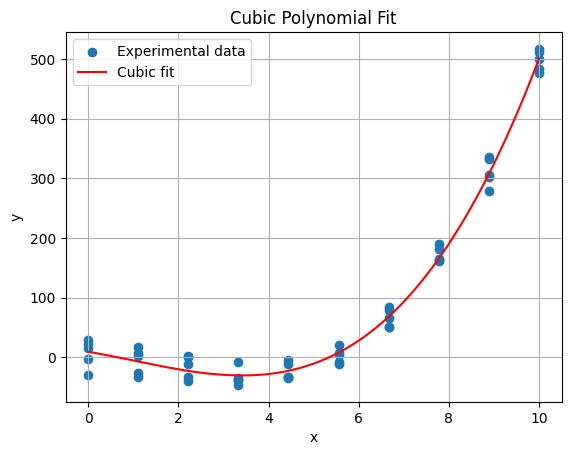

In [6]:
import matplotlib.pyplot as plt

# Extract the x values
x = d[:, 0]

# Extract the five y measurements for each x
y = d[:, 1:]

# Repeat each x value five times
x_all = np.repeat(x, 5)

# Turn the y measurements into one long array
y_all = y.flatten()

# Fit a cubic polynomial and calculate its covariance matrix
coefficients, covariance = np.polyfit(x_all, y_all, 3, cov=True)

# Calculate the uncertainty of each coefficient
uncertainty = np.sqrt(np.diag(covariance))

# Print the coefficients and their uncertainties
print("Cubic coefficients:", coefficients)
print("Coefficient uncertainties:", uncertainty)

# Calculate the fitted values at the measured x positions
y_fit = np.polyval(coefficients, x_all)

# Calculate the residuals between the measured and fitted values
residuals = y_all - y_fit

# Calculate the root mean square error
rmse = np.sqrt(np.mean(residuals**2))

# Print the RMSE
print("RMSE:", rmse)

# Create smooth x values for plotting
x_smooth = np.linspace(0, 10, 200)

# Calculate the fitted curve at the smooth x values
y_smooth = np.polyval(coefficients, x_smooth)

# Plot the experimental data
plt.scatter(x_all, y_all, label="Experimental data")

# Plot the cubic fit
plt.plot(x_smooth, y_smooth, color="red", label="Cubic fit")

# Label the plot
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()

## b) Your manager thinks this should be a quadratic. Which do you think it should be and why?

{Answer}

Quadratic RMSE: 26.970099312022167
Cubic RMSE: 16.59882332244367


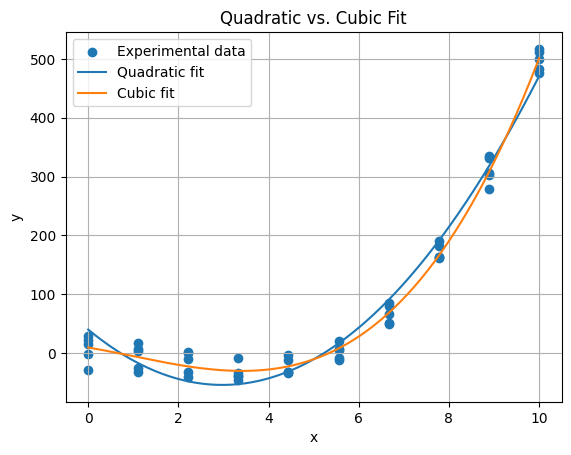

In [7]:

# Fit a quadratic polynomial to the data
quad_coefficients = np.polyfit(x_all, y_all, 2)

# Calculate the quadratic model's predicted values
quad_fit = np.polyval(quad_coefficients, x_all)

# Calculate the quadratic model's RMSE
quad_rmse = np.sqrt(np.mean((y_all - quad_fit)**2))

# Calculate the cubic model's RMSE
cubic_rmse = np.sqrt(np.mean((y_all - y_fit)**2))

# Print both RMSE values
print("Quadratic RMSE:", quad_rmse)
print("Cubic RMSE:", cubic_rmse)

# Calculate smooth quadratic predictions for plotting
quad_smooth = np.polyval(quad_coefficients, x_smooth)

# Plot the original data
plt.scatter(x_all, y_all, label="Experimental data")

# Plot the quadratic fit
plt.plot(x_smooth, quad_smooth, label="Quadratic fit")

# Plot the cubic fit
plt.plot(x_smooth, y_smooth, label="Cubic fit")

# Add labels, a title, and a legend
plt.xlabel("x")
plt.ylabel("y")
plt.title("Quadratic vs. Cubic Fit")
plt.grid(True)
plt.legend()
plt.show()